# GUS04H — Comprehensive Estimation Validation

This notebook validates the demographic cross-table estimates produced
by **GUS04F** (full pipeline).  It runs seven diagnostic checks on every
E\_ subject and presents aggregate metrics plus drill-down tables for
the worst offenders.

### Checks
| # | Check | What it measures |
|---|-------|------------------|
| 1 | Non-negativity | No cell should be negative |
| 2 | Marginal consistency | ogółem = Σ sub-categories |
| 3 | Hierarchical consistency | powiat = Σ gminas, voiv = Σ powiats |
| 4 | Population match | age×sex total ≈ official population |
| 5 | Temporal smoothness | YoY relative jumps < threshold |
| 6 | Sub-division consistency | rodz-3 ≈ rodz-4 + rodz-5 |
| 7 | Educ↔age_sex coherence | educ total ≈ age×sex − young groups |

In [1]:
# ── Cell 1: Imports & database load ────────────────────────────────
import os, sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

REPO = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
TOOLS_PATH = os.path.join(REPO, 'Code', 'tools')
if TOOLS_PATH not in sys.path:
    sys.path.insert(0, TOOLS_PATH)

from geoTERYT_db import (
    load_complete_database,
    LEVEL_GMINA, LEVEL_POWIAT, LEVEL_VOIVODESHIP,
    RODZ_AGGREGATION_SET,
)
from demographic_estimator import DemographicEstimator, E_SUBJECT_NAMES

DATA_ROOT = os.path.join(REPO, '..', '..', 'Data', 'Geospatial')
DB_PATH = os.path.join(DATA_ROOT, 'geoteryt_E.pkl')
assert os.path.isfile(DB_PATH), f'Database not found: {DB_PATH}'

db = load_complete_database(DB_PATH)
print(f'Loaded database with {len(db._records)} records.')

Loading complete database from /Users/jedrek/Documents/Studium Volkswirschaftslehre/3. Semester/Long-run dynamics of wealth inequalities/Paper/local_repo/LRDWI-Paper/../../Data/Geospatial/geoteryt_E.pkl...
  Database version: 4.3
  ✓ Restored old voivodships: 49 rows
  ✓ Restored geometry store: 13,287 unique geometries
  ✓ Restored geometry data for years: [2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2015, 2016, 2017, 2018, 2021, 2022, 2023]
  ✓ Loaded 4613 records
  ✓ Year range: 1999 - 2024
  ✓ Records with geometry: 3662
  ✓ Records with old_woj: 4104
  ✓ Records with data: 4585
  ✓ Records with cross tables: 4585
  ✓ Records with population data: 4583
  ✓ Records with pop_class: 3412
Loaded database with 4613 records.


In [10]:
# ── Cell 2: Run built-in validation for all E_ subjects ────────────

estimator = DemographicEstimator(db, verbose=True)

all_results = {}
for (var_type, section), e_sid in E_SUBJECT_NAMES.items():
    # Check if this subject has data in the database
    has_data = any(
        e_sid in rec.cross_tables
        for rec in db._records.values()
    )
    if not has_data:
        print(f'\n⏭  {e_sid}: no data — skipping')
        continue
    print(f'\n{"="*60}')
    print(f'  Validating {e_sid}')
    print(f'{"="*60}')
    df = estimator.validate_results(e_sid)
    all_results[e_sid] = df
    print(f'  → {len(df)} issues')

print(f'\n\nDone.  Validated {len(all_results)} subjects.')

DemographicEstimator initialised  (Gurobi=YES, IPFN=YES)

  Validating E_age_sex_2000
  Validating E_age_sex_2000: 3058 records, shape=(16, 3)
    [1] Non-negativity: 0 failures
    [2] Marginal consistency: 36 failures (tol=1.0)
    [3] Hierarchical consistency: 0 failures / 10229 checked
    [4] Population match: 0 failures / 64453 checked (tol=0.1%)
    [5] Temporal smoothness: 7075 warnings (threshold=20%)
    [6] Sub-division consistency: 0 failures / 0 checked
    [7] Educ↔age_sex coherence: skipped (not applicable for E_age_sex_2000)
  Validation complete: 7111 issues found
  → 7111 issues

  Validating E_age_sex_1990
  Validating E_age_sex_1990: 3057 records, shape=(16, 3)
    [1] Non-negativity: 0 failures
    [2] Marginal consistency: 0 failures (tol=1.0)
    [3] Hierarchical consistency: 12 failures / 6348 checked
    [4] Population match: 0 failures / 23727 checked (tol=0.1%)
    [5] Temporal smoothness: 3839 warnings (threshold=20%)
    [6] Sub-division consistency: 0 fail

In [11]:
# ── Cell 3: Summary table — issue counts per subject × check ───────

summary_rows = []
for e_sid, df in all_results.items():
    if df.empty:
        summary_rows.append({'subject': e_sid, 'total_issues': 0})
        continue
    for check_name, grp in df.groupby('check'):
        n_fail = (grp['status'] == 'FAIL').sum()
        n_warn = (grp['status'] == 'WARN').sum()
        summary_rows.append({
            'subject': e_sid,
            'check': check_name,
            'FAIL': int(n_fail),
            'WARN': int(n_warn),
            'total': int(n_fail + n_warn),
        })

summary_df = pd.DataFrame(summary_rows)
if 'check' in summary_df.columns:
    pivot = summary_df.pivot_table(
        index='subject', columns='check',
        values='total', aggfunc='sum', fill_value=0,
    )
    pivot['TOTAL'] = pivot.sum(axis=1)
    pivot = pivot.sort_values('TOTAL', ascending=False)
    display(pivot)
else:
    print('No issues found — all checks passed!')

check,educ_age_coherence,hierarchical_consistency,marginal_consistency,temporal_smoothness,TOTAL
subject,,,,,
E_educ_2000,66621.0,102.0,0.0,512.0,67235.0
E_educ_1990,42840.0,0.0,0.0,162.0,43002.0
E_age_sex_2000,0.0,0.0,36.0,7075.0,7111.0
E_age_sex_1990,0.0,12.0,0.0,3839.0,3851.0
E_educ_sex_2000,0.0,45.0,12.0,650.0,707.0
E_educ_sex_1990,0.0,0.0,12.0,656.0,668.0
E_hh_size_2000,0.0,0.0,0.0,51.0,51.0


## Temporal Smoothness Analysis

This section measures the **maximum year-over-year relative change**
for each E\_ subject at the gmina level.  Smooth demographic estimates
should have low max-YoY values (< 5–10%).

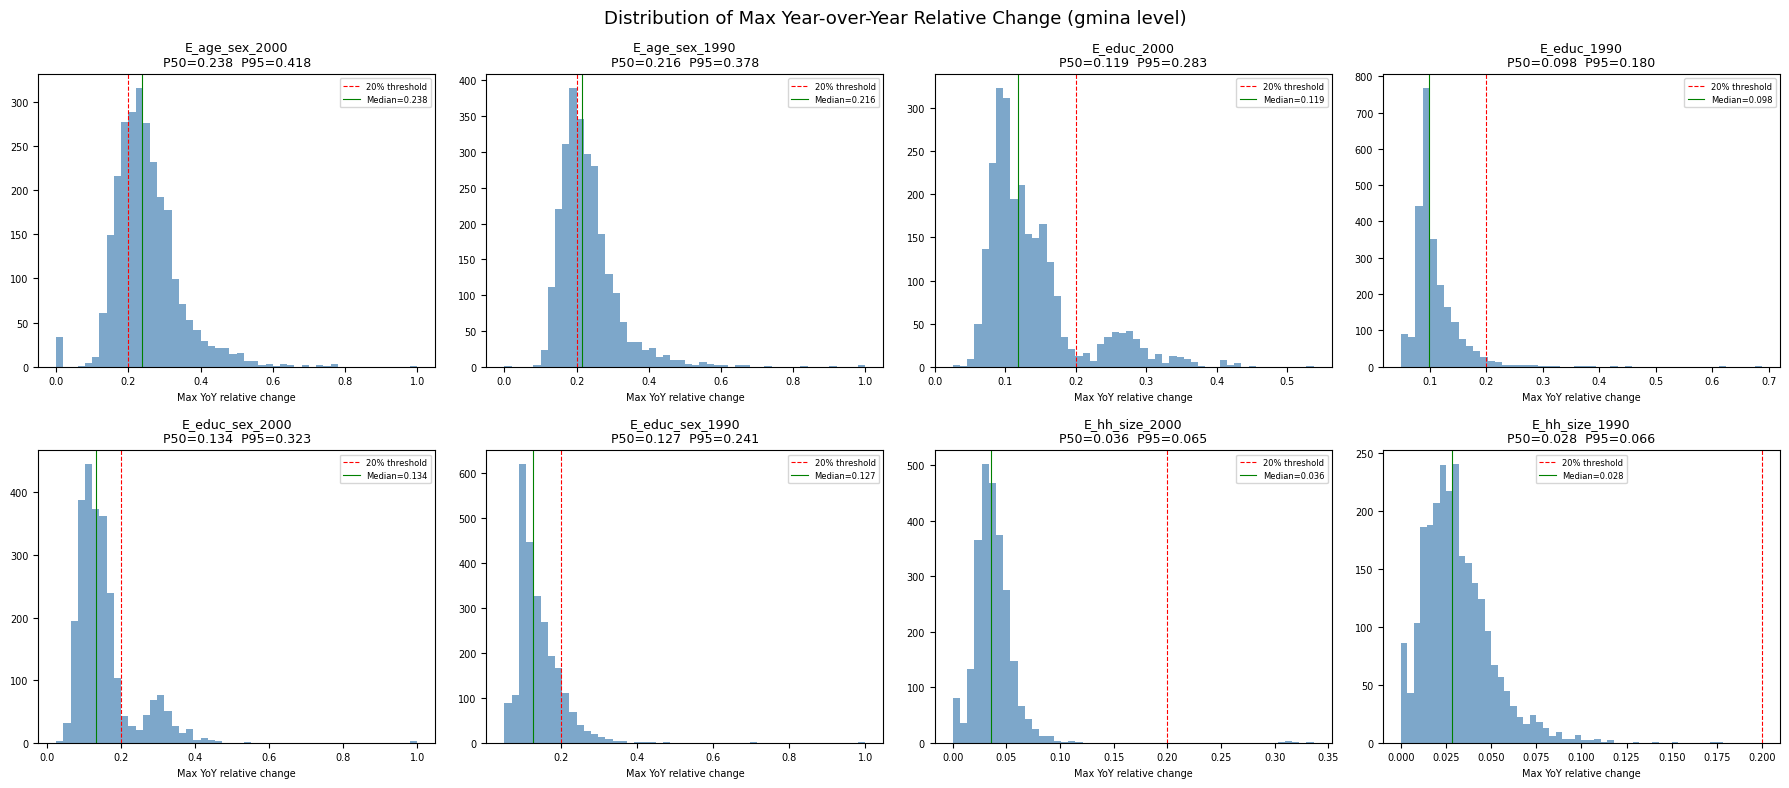

In [12]:
# ── Cell 4: Temporal smoothness — distribution of max-YoY jumps ────

from demographic_estimator import (
    PREDICTION_1990_RANGE, PREDICTION_2000_RANGE, EPSILON,
)

E_SECTIONS = {
    'E_age_sex_2000': PREDICTION_2000_RANGE,
    'E_age_sex_1990': PREDICTION_1990_RANGE,
    'E_educ_2000': PREDICTION_2000_RANGE,
    'E_educ_1990': PREDICTION_1990_RANGE,
    'E_educ_sex_2000': PREDICTION_2000_RANGE,
    'E_educ_sex_1990': PREDICTION_1990_RANGE,
    'E_hh_size_2000': PREDICTION_2000_RANGE,
    'E_hh_size_1990': PREDICTION_1990_RANGE,
}

def compute_max_yoy(db, e_sid, year_range):
    """For each gmina, compute the max YoY relative change across all cells."""
    results = []
    for tid, rec in db._records.items():
        if rec.level != LEVEL_GMINA or rec.rodz not in RODZ_AGGREGATION_SET:
            continue
        ct = rec.cross_tables.get(e_sid)
        if ct is None:
            continue
        yrs = sorted(yr for yr in year_range
                     if yr in ct.tables and ct.tables[yr] is not None
                     and not np.all(np.isnan(ct.tables[yr])))
        if len(yrs) < 2:
            continue
        # Compute mean for relative reference
        tbls = [ct.tables[y] for y in yrs]
        mean_tbl = np.nanmean(np.stack(tbls), axis=0)
        max_change = 0.0
        worst_pair = None
        for i in range(1, len(yrs)):
            if yrs[i] - yrs[i-1] > 1:
                continue
            delta = np.abs(tbls[i] - tbls[i-1])
            with np.errstate(divide='ignore', invalid='ignore'):
                rel = delta / (np.abs(mean_tbl) + EPSILON)
            mr = float(np.nanmax(rel))
            if mr > max_change:
                max_change = mr
                worst_pair = (yrs[i-1], yrs[i])
        results.append({
            'teryt_id': tid,
            'name': rec.name,
            'max_yoy_rel': max_change,
            'worst_years': worst_pair,
        })
    return pd.DataFrame(results)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Distribution of Max Year-over-Year Relative Change (gmina level)', fontsize=13)

for ax, (e_sid, yr_range) in zip(axes.ravel(), E_SECTIONS.items()):
    df = compute_max_yoy(db, e_sid, yr_range)
    if df.empty:
        ax.set_title(f'{e_sid}\n(no data)', fontsize=9)
        continue
    ax.hist(df['max_yoy_rel'].clip(upper=1.0), bins=50, color='steelblue', alpha=0.7)
    ax.axvline(0.20, color='red', linestyle='--', linewidth=0.8, label='20% threshold')
    median = df['max_yoy_rel'].median()
    pct95 = df['max_yoy_rel'].quantile(0.95)
    ax.axvline(median, color='green', linestyle='-', linewidth=0.8, label=f'Median={median:.3f}')
    ax.set_title(f'{e_sid}\nP50={median:.3f}  P95={pct95:.3f}', fontsize=9)
    ax.set_xlabel('Max YoY relative change', fontsize=7)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=6)

fig.tight_layout()
plt.show()

In [13]:
# ── Cell 5: Worst temporal offenders (top 20) ──────────────────────

for e_sid, yr_range in E_SECTIONS.items():
    df = compute_max_yoy(db, e_sid, yr_range)
    if df.empty:
        continue
    top = df.nlargest(50, 'max_yoy_rel')[['teryt_id', 'name', 'max_yoy_rel', 'worst_years']]
    n_above = (df['max_yoy_rel'] > 0.20).sum()
    print(f'\n{e_sid}: {n_above}/{len(df)} gminas with max YoY > 20%')
    display(top)


E_age_sex_2000: 1902/2655 gminas with max YoY > 20%


,teryt_id,name,max_yoy_rel,worst_years
2495,1821022,Cisna,1.154131,"(2019, 2020)"
1546,2005022,Białowieża,0.774244,"(2009, 2010)"
2504,2818012,Banie Mazurskie,0.771859,"(2019, 2020)"
2109,2814112,Stawiguda,0.764830,"(2019, 2020)"
349,0603052,Dubienka,0.755773,"(2003, 2004)"
1213,1429032,Ceranów,0.730178,"(2019, 2020)"
2532,2011043,Krynki,0.729712,"(2019, 2020)"
2427,3211033,Nowe Warpno,0.686773,"(2000, 2001)"
2027,2802042,Lelkowo,0.686259,"(2019, 2020)"
1081,1415022,Czarnia,0.659143,"(2009, 2010)"



E_age_sex_1990: 1601/2660 gminas with max YoY > 20%


,teryt_id,name,max_yoy_rel,worst_years
1828,2408052,Wyry,1.399121,"(1998, 1999)"
676,1008072,Pabianice,1.260932,"(1996, 1997)"
852,1207122,Tymbark,1.059080,"(1996, 1997)"
1865,2414042,Bojszowy,0.916020,"(1998, 1999)"
1835,2410022,Kobiór,0.837778,"(1998, 1999)"
327,0601152,Sosnówka,0.725519,"(1988, 1989)"
1552,2005042,Czyże,0.676262,"(1997, 1998)"
1864,2414031,Lędziny,0.674294,"(1998, 1999)"
1890,2417052,Koszarawa,0.659412,"(1998, 1999)"
1862,2414011,Bieruń,0.640029,"(1998, 1999)"



E_educ_2000: 354/2557 gminas with max YoY > 20%


...

,teryt_id,name,max_yoy_rel,worst_years
1084,1415022,Czarnia,5.864829,"(2001, 2002)"
1102,1416092,Szulborze Wielkie,2.477627,"(2001, 2002)"
1988,2609011,Sandomierz,0.696688,"(2001, 2002)"
2430,3211012,Dobra (Szczecińska),0.480873,"(2001, 2002)"
2431,3211022,Kołbaskowo,0.474442,"(2001, 2002)"
1827,2408042,Ornontowice,0.448746,"(2001, 2002)"
658,1006082,Nowosolna,0.442706,"(2001, 2002)"
1117,1418052,Prażmów,0.424572,"(2001, 2002)"
1722,2213021,Skórcz,0.406349,"(2001, 2002)"
1234,1432072,Stare Babice,0.402203,"(2001, 2002)"



E_hh_size_2000: 8/2557 gminas with max YoY > 20%


,teryt_id,name,max_yoy_rel,worst_years
130,0221072,Stare Bogaczowice,0.336406,"(2011, 2012)"
127,0221042,Czarny Bór,0.331600,"(2011, 2012)"
131,0221082,Walim,0.318037,"(2010, 2011)"
126,0221031,Szczawno-Zdrój,0.316356,"(2010, 2011)"
128,0221053,Głuszyca,0.316087,"(2010, 2011)"
125,0221021,Jedlina-Zdrój,0.315086,"(2011, 2012)"
124,0221011,Boguszów-Gorce,0.314389,"(2010, 2011)"
129,0221063,Mieroszów,0.307983,"(2010, 2011)"
1329,1611022,Jemielnica,0.120140,"(2002, 2003)"
1774,2405032,Gierałtowice,0.116217,"(2002, 2003)"



E_hh_size_1990: 0/2520 gminas with max YoY > 20%


,teryt_id,name,max_yoy_rel,worst_years
910,1213052,Osiek,0.178514,"(2001, 2002)"
1569,2007062,Przytuły,0.174937,"(2001, 2002)"
1338,1609112,Tarnów Opolski,0.151965,"(2001, 2002)"
2461,3215043,Borne Sulinowo,0.141595,"(2001, 2002)"
873,1210052,Kamionka Wielka,0.128932,"(2001, 2002)"
2431,3211022,Kołbaskowo,0.116951,"(2001, 2002)"
2430,3211012,Dobra (Szczecińska),0.114365,"(2001, 2002)"
1612,2012092,Wiżajny,0.111004,"(2001, 2002)"
590,0810032,Brzeźnica,0.110190,"(2001, 2002)"
1089,1415072,Łyse,0.109047,"(2001, 2002)"


## Hierarchical Consistency Analysis

Checks that **parent = Σ children** at each level of the
administrative hierarchy.

In [14]:
# ── Cell 6: Hierarchical consistency — powiat = Σ gminas ───────────

from demographic_estimator import _get_aggregation_children

def check_hierarchy(db, e_sid, year_range):
    """Check parent = Σ children for powiats."""
    rows = []
    for tid, rec in db._records.items():
        if rec.level != LEVEL_POWIAT:
            continue
        pct = rec.cross_tables.get(e_sid)
        if pct is None:
            continue
        for yr in year_range:
            ptbl = pct.tables.get(yr)
            if ptbl is None or np.all(np.isnan(ptbl)):
                continue
            children = _get_aggregation_children(rec, db, yr)
            child_sum = np.zeros_like(ptbl)
            n_ch = 0
            for ch_tid in children:
                ch_rec = db._records.get(ch_tid)
                if ch_rec is None:
                    continue
                ch_ct = ch_rec.cross_tables.get(e_sid)
                if ch_ct is None:
                    continue
                ch_tbl = ch_ct.tables.get(yr)
                if ch_tbl is None or ch_tbl.shape != ptbl.shape:
                    continue
                child_sum += np.nan_to_num(ch_tbl, nan=0.0)
                n_ch += 1
            if n_ch == 0:
                continue
            p_total = float(np.nansum(ptbl))
            c_total = float(np.nansum(child_sum))
            max_cell = float(np.max(np.abs(child_sum - np.nan_to_num(ptbl, nan=0.0))))
            pct_err = 100 * abs(p_total - c_total) / max(p_total, 1) if p_total > 0 else 0
            rows.append({
                'teryt_id': tid, 'name': rec.name, 'year': yr,
                'parent_total': p_total, 'children_total': c_total,
                'pct_err': pct_err, 'max_cell_diff': max_cell,
                'n_children': n_ch,
            })
    return pd.DataFrame(rows)

for e_sid, yr_range in E_SECTIONS.items():
    df = check_hierarchy(db, e_sid, yr_range)
    if df.empty:
        print(f'{e_sid}: no hierarchical data')
        continue
    n_fail = (df['pct_err'] > 0.5).sum()
    med = df['pct_err'].median()
    p95 = df['pct_err'].quantile(0.95)
    print(f'{e_sid}: {n_fail}/{len(df)} failures (>0.5%)  '
          f'median={med:.4f}%  P95={p95:.4f}%')
    if n_fail > 0:
        worst = df.nlargest(25, 'pct_err')[['teryt_id', 'name', 'year', 'pct_err', 'max_cell_diff']]
        display(worst)

E_age_sex_2000: 0/10229 failures (>0.5%)  median=0.0000%  P95=0.0000%
E_age_sex_1990: 12/6348 failures (>0.5%)  median=0.0000%  P95=0.0000%


,teryt_id,name,year,pct_err,max_cell_diff
4445,2413000,tarnogórski,1995,1.583639e+01,2.013248e+04
4446,2413000,tarnogórski,1996,1.554688e+01,1.973941e+04
4447,2413000,tarnogórski,1997,1.505821e+01,1.910390e+04
4480,2415000,wodzisławski,1996,1.159252e+01,1.837194e+04
4479,2415000,wodzisławski,1995,1.150785e+01,1.821968e+04
1658,1008000,pabianicki,1995,5.631802e+00,6.850299e+03
1659,1008000,pabianicki,1996,5.613914e+00,6.828709e+03
2033,1207000,limanowski,1996,4.614592e+00,5.315041e+03
2032,1207000,limanowski,1995,4.531046e+00,5.179439e+03
2100,1211000,nowotarski,1995,2.323083e+00,4.045812e+03


E_educ_2000: 307/10226 failures (>0.5%)  median=0.0000%  P95=0.0000%


,teryt_id,name,year,pct_err,max_cell_diff
10198,1465000,Warszawa,2011,5.618132,33176.465087
4093,1418000,piaseczyński,2011,4.601050,1869.835881
4174,1421000,pruszkowski,2011,4.465545,1641.985713
4714,1464000,Siedlce,2011,4.403635,793.416540
3823,1408000,legionowski,2011,4.248418,979.740898
4444,1432000,warszawski zachodni,2011,4.175354,954.236008
3742,1405000,grodziski,2011,4.113878,703.831295
4633,1461000,Ostrołęka,2011,4.064581,431.306818
4687,1463000,Radom,2011,4.023842,1788.631461
4498,1434000,wołomiński,2011,3.924135,1762.624834


E_educ_1990: 0/6348 failures (>0.5%)  median=0.0000%  P95=0.0000%
E_educ_sex_2000: 310/10226 failures (>0.5%)  median=0.0000%  P95=0.0000%


,teryt_id,name,year,pct_err,max_cell_diff
10198,1465000,Warszawa,2011,5.669072,33469.425179
4093,1418000,piaseczyński,2011,4.646663,1888.016868
4174,1421000,pruszkowski,2011,4.514363,1659.618962
4714,1464000,Siedlce,2011,4.448120,801.241790
3823,1408000,legionowski,2011,4.295994,990.505808
4444,1432000,warszawski zachodni,2011,4.218968,964.038675
3742,1405000,grodziski,2011,4.160272,711.627791
4633,1461000,Ostrołęka,2011,4.113860,436.437361
4687,1463000,Radom,2011,4.067771,1807.842379
4498,1434000,wołomiński,2011,3.969668,1782.651652


E_educ_sex_1990: 0/6348 failures (>0.5%)  median=0.0000%  P95=0.0000%
E_hh_size_2000: 0/10226 failures (>0.5%)  median=0.0000%  P95=0.0000%
E_hh_size_1990: 0/6348 failures (>0.5%)  median=0.0000%  P95=0.0000%


## Education ↔ Age×Sex Population Coherence

Education data covers population aged 13+ (1990 section) or 15+ (2000 section).
The total across education categories should approximately equal the
age×sex total minus the 0-4, 5-9, and 10-14 age groups.

E_educ_2000: median_err=-77.55%  [P5, P95]=[-79.17%, -75.94%]  |err|>10%: 66621/66621


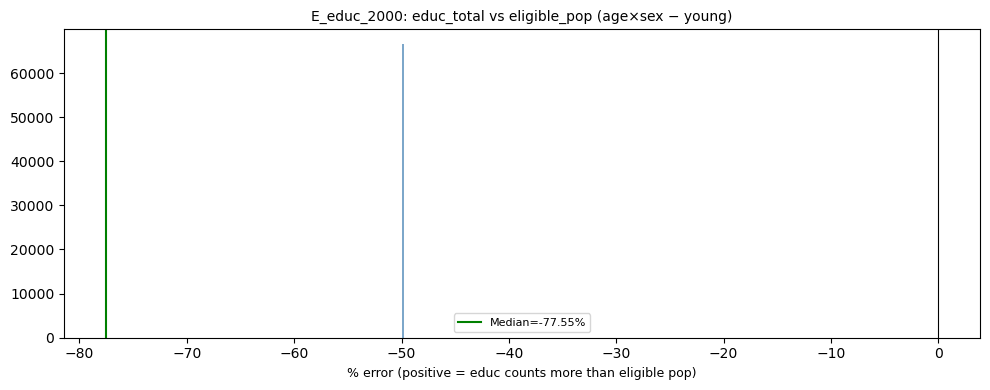

E_educ_1990: median_err=-56.52%  [P5, P95]=[-58.53%, -53.97%]  |err|>10%: 42840/42840


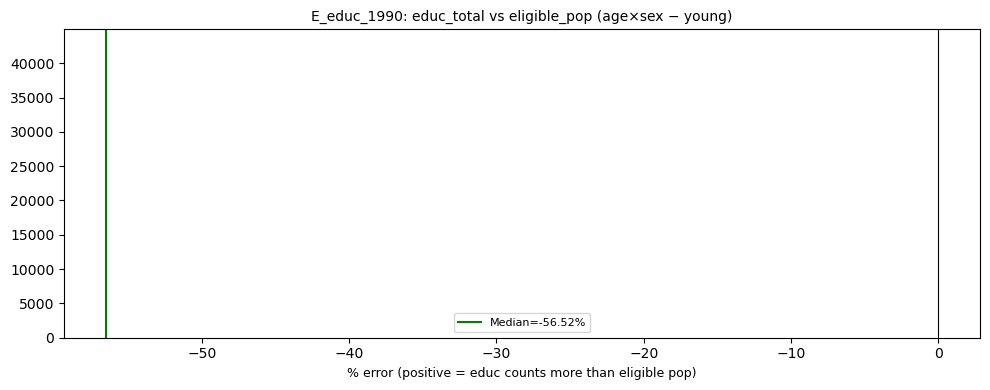

In [15]:
# ── Cell 7: Education ↔ age×sex coherence ──────────────────────────

YOUNG_LABELS = {'0-4', '5-9', '10-14'}

def check_educ_pop_coherence(db, educ_sid, age_sex_sid, year_range):
    """Compare educ total vs age×sex − young groups."""
    rows = []
    for tid, rec in db._records.items():
        if rec.level != LEVEL_GMINA or rec.rodz not in RODZ_AGGREGATION_SET:
            continue
        e_ct = rec.cross_tables.get(educ_sid)
        a_ct = rec.cross_tables.get(age_sex_sid)
        if e_ct is None or a_ct is None:
            continue

        # Identify young-age row indices
        age_dim = a_ct.dim_names[0]
        age_labels = a_ct.dim_labels.get(age_dim, [])
        young_idx = [i for i, lbl in enumerate(age_labels) if lbl in YOUNG_LABELS]

        for yr in year_range:
            e_tbl = e_ct.tables.get(yr)
            a_tbl = a_ct.tables.get(yr)
            if e_tbl is None or a_tbl is None:
                continue
            if np.all(np.isnan(e_tbl)) or np.all(np.isnan(a_tbl)):
                continue

            educ_total = float(np.nansum(e_tbl))
            age_total = float(np.nansum(a_tbl))
            young_pop = sum(float(np.nansum(a_tbl[yi])) for yi in young_idx)
            eligible = age_total - young_pop
            if eligible <= 0:
                continue
            pct_err = 100 * (educ_total - eligible) / eligible
            rows.append({
                'teryt_id': tid, 'name': rec.name, 'year': yr,
                'educ_total': educ_total,
                'eligible_pop': eligible,
                'pct_err': pct_err,
            })
    return pd.DataFrame(rows)

educ_pairs = [
    ('E_educ_2000', 'E_age_sex_2000', PREDICTION_2000_RANGE),
    ('E_educ_1990', 'E_age_sex_1990', PREDICTION_1990_RANGE),
]

for educ_sid, age_sid, yr_range in educ_pairs:
    df = check_educ_pop_coherence(db, educ_sid, age_sid, yr_range)
    if df.empty:
        print(f'{educ_sid}: no data for coherence check')
        continue
    med = df['pct_err'].median()
    p05 = df['pct_err'].quantile(0.05)
    p95 = df['pct_err'].quantile(0.95)
    n_bad = (df['pct_err'].abs() > 10).sum()
    print(f'{educ_sid}: median_err={med:.2f}%  [P5, P95]=[{p05:.2f}%, {p95:.2f}%]  |err|>10%: {n_bad}/{len(df)}')

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(df['pct_err'].clip(-50, 50), bins=100, color='steelblue', alpha=0.7)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.axvline(med, color='green', linestyle='-', label=f'Median={med:.2f}%')
    ax.set_title(f'{educ_sid}: educ_total vs eligible_pop (age×sex − young)', fontsize=10)
    ax.set_xlabel('% error (positive = educ counts more than eligible pop)', fontsize=9)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

## Census Year Fidelity

Checks that census-year data is preserved exactly by the estimation
pipeline.  The E\_ tables at census years should match the original
M\_ tables (observed data has highest priority).

In [16]:
# ── Cell 8: Census year fidelity ──────────────────────────────────

CENSUS_YEARS = [1988, 2002, 2011, 2021]
E_TO_M = {
    'E_age_sex_2000':  'M_age_sex',
    'E_age_sex_1990':  'M_age_sex',
    'E_educ_2000':     'M_educ_2000',
    'E_educ_1990':     'M_educ_1990',
    'E_educ_sex_2000': 'M_educ_sex_2000',
    'E_educ_sex_1990': 'M_educ_sex_1990',
    'E_hh_size_2000':  'M_hh_size_2000',
    'E_hh_size_1990':  'M_hh_size_1990',
}

fidelity_rows = []
for e_sid, m_sid in E_TO_M.items():
    n_match = 0
    n_mismatch = 0
    n_checked = 0
    for tid, rec in db._records.items():
        if rec.level != LEVEL_GMINA or rec.rodz not in RODZ_AGGREGATION_SET:
            continue
        e_ct = rec.cross_tables.get(e_sid)
        m_ct = rec.cross_tables.get(m_sid)
        if e_ct is None or m_ct is None:
            continue
        for cy in CENSUS_YEARS:
            e_tbl = e_ct.tables.get(cy)
            m_tbl = m_ct.tables.get(cy)
            if e_tbl is None or m_tbl is None:
                continue
            if np.all(np.isnan(e_tbl)) or np.all(np.isnan(m_tbl)):
                continue
            if e_tbl.shape != m_tbl.shape:
                continue
            n_checked += 1
            max_diff = float(np.nanmax(np.abs(
                np.nan_to_num(e_tbl, nan=0.0) - np.nan_to_num(m_tbl, nan=0.0)
            )))
            if max_diff < 1.0:
                n_match += 1
            else:
                n_mismatch += 1
    fidelity_rows.append({
        'e_sid': e_sid, 'checked': n_checked,
        'match': n_match, 'mismatch': n_mismatch,
        'fidelity_pct': 100 * n_match / max(n_checked, 1),
    })

fidelity_df = pd.DataFrame(fidelity_rows)
display(fidelity_df.style.format({'fidelity_pct': '{:.1f}%'}))

,e_sid,checked,match,mismatch,fidelity_pct
0,E_age_sex_2000,7437,7437,0,100.0%
1,E_age_sex_1990,2657,2657,0,100.0%
2,E_educ_2000,4955,4955,0,100.0%
3,E_educ_1990,4957,4957,0,100.0%
4,E_educ_sex_2000,4955,4955,0,100.0%
5,E_educ_sex_1990,2478,2478,0,100.0%
6,E_hh_size_2000,4955,4955,0,100.0%
7,E_hh_size_1990,4957,4957,0,100.0%


## Observed Year Coverage

Shows the `observed_years` set on E\_ CrossTables to verify that
the pipeline correctly tags which years were observed vs estimated.

In [17]:
# ── Cell 9: Observed year coverage per E_ subject ─────────────────

obs_rows = []
for e_sid in E_SECTIONS:
    obs_year_counts = {}
    n_with_obs = 0
    n_total = 0
    for tid, rec in db._records.items():
        if rec.level != LEVEL_GMINA or rec.rodz not in RODZ_AGGREGATION_SET:
            continue
        ct = rec.cross_tables.get(e_sid)
        if ct is None:
            continue
        n_total += 1
        if hasattr(ct, 'observed_years') and ct.observed_years:
            n_with_obs += 1
            for yr in ct.observed_years:
                obs_year_counts[yr] = obs_year_counts.get(yr, 0) + 1
    top_years = sorted(obs_year_counts.items())
    obs_rows.append({
        'e_sid': e_sid,
        'gminas_total': n_total,
        'gminas_with_obs': n_with_obs,
        'obs_years': {yr: cnt for yr, cnt in top_years},
    })

obs_df = pd.DataFrame(obs_rows)
for _, row in obs_df.iterrows():
    print(f"\n{row['e_sid']}: {row['gminas_with_obs']}/{row['gminas_total']} gminas with observed data")
    if row['obs_years']:
        for yr, cnt in sorted(row['obs_years'].items()):
            print(f'  {yr}: {cnt} gminas')


E_age_sex_2000: 2660/2660 gminas with observed data
  1999: 2479 gminas
  2000: 2479 gminas
  2001: 2479 gminas
  2002: 2479 gminas
  2003: 2479 gminas
  2004: 2479 gminas
  2005: 2479 gminas
  2006: 2479 gminas
  2007: 2479 gminas
  2008: 2479 gminas
  2009: 2479 gminas
  2010: 2480 gminas
  2012: 2480 gminas
  2013: 2480 gminas
  2014: 2480 gminas
  2015: 2479 gminas
  2016: 2479 gminas
  2017: 2479 gminas
  2018: 2479 gminas
  2019: 2478 gminas
  2020: 2478 gminas
  2021: 2478 gminas
  2022: 2478 gminas
  2023: 2478 gminas
  2024: 2478 gminas

E_age_sex_1990: 2658/2660 gminas with observed data
  1995: 2652 gminas
  1996: 2652 gminas
  1997: 2655 gminas
  1998: 2658 gminas
  1999: 2658 gminas
  2000: 2658 gminas
  2001: 2658 gminas
  2002: 2657 gminas

E_educ_2000: 2557/2557 gminas with observed data
  2002: 2478 gminas
  2021: 2477 gminas

E_educ_1990: 2520/2520 gminas with observed data
  1988: 2479 gminas
  2002: 2478 gminas

E_educ_sex_2000: 2557/2557 gminas with observed data


## Summary

This notebook provides a comprehensive assessment of estimation quality.
Key metrics to watch:

- **Temporal smoothness**: P95 max-YoY < 20% for all subjects
- **Hierarchical consistency**: 0% failures at 0.5% tolerance
- **Census fidelity**: 100% match at census years
- **Educ↔age coherence**: median error near 0%, spread < ±10%